# Homework 1 - data validation & cleaning (deadline 16. 11. 2025, 23:59)

In short, the main task is to clean The Metropolitan Museum of Art Open Access dataset.
  
> The instructions are not given in detail: It is up to you to come up with ideas on how to fulfill the particular tasks as best as possible!

However, we **strongly recommend and require** the following:
* Follow the assignment step by step. Number each step.
* Most steps contain the number of features that should be treated. You can preprocess more features. However, it does not mean the teacher will give you more points. Focus on quality, not quantity.
* Properly comment on all your steps. Use Markdown cells and visualizations. Comments are evaluated for 2 points of the total, together with the final presentation of the solution. However, it is not desirable to write novels! 
* This task is timewise and computationally intensive. Do not leave it to the last minute.
* Hand in a notebook that has already been run (i.e., do not delete outputs before handing in).

## What are you supposed to do:

  1. Download the dataset MetObjects.csv from the repository https://github.com/metmuseum/openaccess/.
1. Check consistency (i.e., that the same things are represented in the same way - datatypewise) of at least **three features** where you expect problems (including the "Object Name" feature). You can propose how to clean the selected features. However, **do not apply cleaning** (in your interest) 🙂 _(1.5 points)_
1. Select at least **two features** (i.e., one couple) where you expect integrity problems (describe your choice) and check the integrity of those features. By integrity, we mean correct logical relations between features (e.g., female names for females only) - Poskozena nebo chybejici data. _(2 points)_
  1. Convert at least **five features** to a proper data type. Choose at least one numeric, one categorical (i.e., ordinal or nominal), and one datetime. _(1.5 points)_
 1. Find some outliers and describe your method. _(3 points, depends on creativity)_

1. Detect missing data in at least **three features**, convert them to a proper representation (if they are already not), **and impute missing values in at least one feature using some imputation method**(i.e., imputation by mean or median is too trivial to obtain any points). _(2 + 3 points, depends on creativity)_
  1. Focus more precisely on cleaning the "Medium" feature. As if you were to use it in the KNN classification algorithm later. _(3 points)_
1. Focus on the extraction of the physical dimensions of each item (width, depth, and height in centimeters) from the "Dimensions" feature. _(2 points)_


All your steps, your choices of methods, and the following code **must be commented on!** For text comments (discussion, etc., not code comments), use **Markdown cells**. Comments are evaluated for 2 points together with the final presentation of the solution. 

**If you do all this properly, you will obtain 20 points.**

## Comments

  * Please follow the technical instructions from https://courses.fit.cvut.cz/NI-PDD/homeworks/index.html.
  * Methods that are more complex and were not shown during the tutorials are considered more creative and should be described in detail.
  * English is not compulsory.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [2]:
df = pd.read_csv('MetObjects.csv',low_memory=False)
#Columns (5,7,10,11,12,13,14,34,35,36,37,38,39,40,41,42,43,44,45,46) have mixed types

In [3]:
df_original = df

In [4]:
df.shape

(484956, 54)

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head(100)

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,Culture,Period,Dynasty,Reign,Portfolio,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL,Object Date,Object Begin Date,Object End Date,Medium,Dimensions,Credit Line,Geography Type,City,State,County,Country,Region,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,NaN,NaN,NaN,NaN,NaN,16429,Maker,,James Barton Longacre,"American, Delaware County, Pennsylvania 1794–1...",,"Longacre, James Barton",American,1794,1869,NaN,http://vocab.getty.edu/page/ulan/500011409,https://www.wikidata.org/wiki/Q3806459,1853,1853,1853,Gold,Dimensions unavailable,"Gift of Heinz L. Stoppelmann, 1979",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,NaN,NaN,NaN,NaN,NaN,107,Maker,,Christian Gobrecht,1785–1844,,"Gobrecht, Christian",American,1785,1844,NaN,http://vocab.getty.edu/page/ulan/500077295,https://www.wikidata.org/wiki/Q5109648,1901,1901,1901,Gold,Dimensions unavailable,"Gift of Heinz L. Stoppelmann, 1980",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1909–27,1909,1927,Gold,Diam. 11/16 in. (1.7 cm),"Gift of C. Ruxton Love Jr., 1967",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1909–27,1909,1927,Gold,Diam. 11/16 in. (1.7 cm),"Gift of C. Ruxton Love Jr., 1967",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1909–27,1909,1927,Gold,Diam. 11/16 in. (1.7 cm),"Gift of C. Ruxton Love Jr., 1967",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
5,67.265.12,False,False,False,6,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1909–27,1909,1927,Gold,Diam. 11/16 in. (1.7 cm),"Gift of C. Ruxton Love Jr., 1967",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/6,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
6,67.265.13,False,False,False,7,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1909–27,1909,1927,Gold,Diam. 11/16 in. (1.7 cm),"Gift of C. Ruxton Love Jr., 1967",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/7,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Birds|Coins,http://vocab.getty.edu/page/aat/300266506|http...,https://www.wikidata.org/wiki/Q5113|https://ww...
7,67.265.14,False,False,False,8,NaN,The American Wing,1967,Coin,Two

### 1) Mixed data

In [6]:
# display(df.dtypes)
df.info()
# sloupce s mixed typy jsou oznaceny jako object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  object 
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  object 
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  object 
 9   Title                    456153 non-null  object 
 10  Culture                  208190 non-null  object 
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   object 
 13  Reign                    11236 non-null   object 
 14  Port

In [7]:
# pro kazdy radek aplikuje funkci type, ktera vrati typ objektu, pokud ve sloupci existuje víc než 1 typ, sloupec je podezřelý pro tento příklad
for name in df.columns:
    types_in_column = df[name].apply(type).value_counts()
    if len(types_in_column) > 1:
        print(f"\nColumn: {name}")
        print(types_in_column)

        float_values = df[name][df[name].apply(lambda x: isinstance(x, float))].unique()
        print(float_values)
        
# toto není uplně šťastné řešení, pd identifikuje nan jako float a ostatni jako string



Column: Gallery Number
Gallery Number
<class 'float'>    435415
<class 'str'>       49541
Name: count, dtype: int64
[nan]

Column: AccessionYear
AccessionYear
<class 'str'>      481094
<class 'float'>      3862
Name: count, dtype: int64
[nan]

Column: Object Name
Object Name
<class 'str'>      482690
<class 'float'>      2266
Name: count, dtype: int64
[nan]

Column: Title
Title
<class 'str'>      456153
<class 'float'>     28803
Name: count, dtype: int64
[nan]

Column: Culture
Culture
<class 'float'>    276766
<class 'str'>      208190
Name: count, dtype: int64
[nan]

Column: Period
Period
<class 'float'>    393813
<class 'str'>       91143
Name: count, dtype: int64
[nan]

Column: Dynasty
Dynasty
<class 'float'>    461755
<class 'str'>       23201
Name: count, dtype: int64
[nan]

Column: Reign
Reign
<class 'float'>    473720
<class 'str'>       11236
Name: count, dtype: int64
[nan]

Column: Portfolio
Portfolio
<class 'float'>    458442
<class 'str'>       26514
Name: count, dtype: int

In [8]:
import re

print("unique values: ", len(df["Object Name"].dropna().unique()), "total values: ", len(df["Object Name"].dropna()))
unique_values = df["Object Name"].dropna().unique() 

values_with_numbers = [v for v in unique_values if isinstance(v, str) and re.search(r'\d', str(v).strip())]

print(values_with_numbers[:50])
#print(unique_values[:50])
#print(unique_values)

duplicates = df["Object Name"][df["Object Name"].duplicated()].unique()
print((duplicates))



unique values:  28631 total values:  482690
['Armor in the style of the 15th century', 'Taces (4)', 'Crossbow with bolts (6)', 'Reproduction of a sword in the style of ca. 600', 'Calthrops (2)', '2 Swords (Dha) with scabbard', 'Badge or harness pendant08', 'Badge or harness pendant108', 'Plates (39) of ceremonial armor', 'Scales of jazerans (3)', 'Buckles (4)', 'Spoons (2)', 'Cabasset in late 16th century style', 'Barbute in 15th century style', 'Greave and Sabaton in 16th century style', 'Jousting Helmet in late 15th century style', 'Helmet (<i>Hoshi kabuto</i>) in the 16th-century style', 'Ammunition belt (Kamr) Object Cards.  S. martz, 11.with powder flask and pouches', 'Matchlock gun in the style of the 16th century', 'Kidney Dagger in 15th century style', 'Roundel dagger in 16th century style', 'Prototype for helmet model no. 2', 'Rubbing of the front of a Wei dynasty Trübner stele (acc. no. 29.72)', 'Twentieth century rubbing of stele of Northern Wei dynasty (386–534)', 'DO NOT U

Object name je pravděpodobně nějaká kategorie artefaktu. Unikátních hodnot je jen 28000 v porovnání s celkovým počtem 482000, to znamená, že hodnoty ani z daleka nejsou unikátní a řádky by se daly roztřídit do kategorií. 
Při seznámení s daty jsem sledoval, zda se ve sloupci neobjevují samotná čísla nebo jiné datové typy než string. Jediná čísla jsou letopočty nebo nějaká forma ID, které se dá také považovat za jméno a nenese žádný hlubší význam. 

Sloupec bych převedl na nominalni kategorická data

In [9]:
# df["Artist Gender"]

In [10]:
print("missing values", df["Gallery Number"].isnull().sum())
df["Gallery Number"].dropna().unique()

missing values 435415


array(['774', '706', '724', '741', '728', '719', '718', '729', '712',
       '516', '737', '738', '701', '734', '708', '722', '713', '730',
       '752', '736', '714', '740', '743', '725', '739', '745', '700',
       '704', '750', '512', '751', '717', '749', '733', '773', '710',
       '744', '726', '705', '732', '731', '723', '715', '508', '510',
       '747', '756', '720', '721', '766', '761', '762', '754', '372',
       '554', '707', '764', '768', '771', '760', '758', '759', '763',
       '681', '824', '769', '748', '753', '772', '755', 'in Great Hall',
       '767', '770', '765', '703', '809', '735', '727', '599', '742',
       '757', '380', '378', '371', '379', '375', '374', '376', '373',
       '455', '377', '370', '459', '509', '457', '307', '303', '304',
       '306', '014', '503', '010', '544', '301', '002', '305', '216',
       '236', '222', '207', '208', '223', '210', '213', '230', '214',
       '251', '244', '235', '237', '247', '249', '248', '250', '204',
       '238', '25

Toto vypadá, že by se taky převedlo na kategorická data. Sloupec sice vypadá jako čísla, ale občas se ukáže string se jménem galerie. To naznačuje, že čísla jsou spíše identifikace než že by nesla nějakou informaci po seřazení.

In [11]:
print("missing values", df["Artist Begin Date"].isnull().sum())
df["Artist Begin Date"].dropna().unique()

missing values 202443


array(['1794      ', '1785      ', '1867      ', ...,
       '1537      |1586      |1498      ',
       '1537      |1498      |1586      ',
       '1586      |1537      |1498      '], dtype=object)

Toto by se dalo vyčistit od přebytečných | a pak převést na nějakou formu reprezentaci datumu. Zde by asi stačil integer, protože zde je datum jenom rok.

### 2) Integrita dat

V "Object Date" sloupci chybí hodnoty a někdy jsou zde hodnoty takovéhle "ca. 1785", ale sloupce "Object Begin Date" a "Object End Date" jsou plně vyplněné a jsou typu integer. Sloupec je z nich složen tak se dá doplnit. Dále se dá zkontrolovat, aby begin byl vždy menší než end a že časový rozsah není nepřiměřeně velký.

In [12]:
invalid_rows = df[
                    (df["Object Begin Date"] > df["Object End Date"]) | 
                    (df["Object End Date"] - df["Object Begin Date"] > 100)
                ]

print(len(invalid_rows))
display(invalid_rows.head(100))

72446


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,Culture,Period,Dynasty,Reign,Portfolio,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL,Object Date,Object Begin Date,Object End Date,Medium,Dimensions,Credit Line,Geography Type,City,State,County,Country,Region,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
282,13.7.10,False,False,False,327,774,The American Wing,1913,Mug,Barrel Mug,American,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1700–1900,1700,1900,Earthenware,5 3/4 x 6 x 4 5/8 in. (14.6 x 15.2 x 11.7 cm),"Rogers Fund, 1913",Made in,NaN,NaN,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search...,https://www.wikidata.org/wiki/Q116390238,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
283,13.7.11,False,False,False,328,774,The American Wing,1913,Mug,Barrel Mug,American,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1700–1900,1700,1900,Probably earthenware,4 1/8 x 4 5/8 x 3 5/8 in. (10.5 x 11.7 x 9.2 cm),"Rogers Fund, 1913",Made in,NaN,NaN,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search...,https://www.wikidata.org/wiki/Q116390242,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
393,10.125.591,False,False,True,450,774,The American Wing,1910,Bellows,Bellows,American,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1700–1900,1700,1900,"Wood; Walnut, leather, brass",H. 20 in. (50.8 cm),"Gift of Mrs. Russell Sage, 1909",Probably made in,NaN,NaN,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search...,https://www.wikidata.org/wiki/Q116390289,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
408,83.2.215,False,False,False,467,NaN,The American Wing,1883,Painting,Plaque Portrait of Benjamin Franklin,NaN,NaN,NaN,NaN,NaN,1199440,Artist|Artist,After|,Jacques Thouron|Weyller,|,|,"Thouron, Jacques|Weyller",|,|,9999 |9999,|,|,|,1776–1883,1776,1883,Enamel,2 3/8 x 2 in. (6 x 5.1 cm),"Gift of William H. Huntington, 1883",Made in,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Benjamin Franklin|Men|Portraits,http://vocab.getty.edu/page/ulan/500331804|htt...,https://www.wikidata.org/wiki/Q34969|https://w...
409,83.2.216,False,False,False,468,NaN,The American Wing,1883,Painting,Plaque Portrait of Benjamin Franklin,NaN,NaN,NaN,NaN,NaN,119,Artist,After,Jacques Thouron,,,"Thouron, Jacques",,,9999,NaN,NaN,NaN,1776–1883,1776,1883,Ivory,Diam. 3 3/16 in. (8.1 cm),"Gift of William H. Huntington, 1883",Made in,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Benjamin Franklin|Men|Portraits,http://vocab.getty.edu/page/ulan/500331804|htt...,https://www.wikidata.org/wiki/Q34969|https://w...
410,83.2.219,False,False,False,469,NaN,The American Wing,1883,Painting,Plaque Portrait of Benjamin Franklin,NaN,NaN,NaN,NaN,NaN,119,Artist,After,Jacques Thouron,,,"Thouron, Jacques",,,9999,NaN,NaN,NaN,1776–1883,1776,1883,Enamel,3 7/8 x 2 7/8 in. (9.8 x 7.3 cm),"Gift of William H. Huntington, 1883",Made in,NaN,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Benjamin Franklin|Men|Portraits,http://vocab.getty.edu/page/ulan/500331804|htt...,https://www.wikidata.org/wiki/Q34969|https://w...
411,83.2.220,False,False,True,470,NaN,The American Wing,1883,Painting,Plaque Portrait of Benjam

Zároveň by Object begin a Object end měl být v autorově životě. Toto půjde udělat až po vyčištění Artist begin a end a převedení na číselný příznak.

In [13]:
#invalid_rows = df[
#                    (df["Object Begin Date"] < df["Artist Begin Date"]) | 
#                    (df["Object End Date"] > df["Artist End Date"])
#                 ]
#display(invalid_rows[["Object Begin Date", "Object End Date", "Artist Begin Date", "Artist End Date"]])

### 3) Převod 5ti sloupců na správný typ

In [14]:
df["AccessionYear"] = pd.to_datetime(df["AccessionYear"], format='%Y', errors='coerce')


V některých případech je v původních datech vícero datum narození umělce, tato funkce vezme první datum a ostatní zahodí. Dalo by se informaci nějak zachovat, například vzít data a zprůměrovat je.

Zároveň v datech jsou NaN, takže sloupec nepřevedu na int ale na float

In [15]:
def parse_artist_dates(value):
    if pd.isna(value):
        return np.nan
    value = value.strip()
    if '|' in value:
        value = value.split('|')[0].strip()
    try:
        return int(value)
    except:
        return np.nan

In [16]:
df["Artist Begin Date"].unique()

array(['1794      ', '1785      ', nan, ...,
       '1537      |1586      |1498      ',
       '1537      |1498      |1586      ',
       '1586      |1537      |1498      '], dtype=object)

In [17]:
df["Artist Begin Date"] = df["Artist Begin Date"].apply(parse_artist_dates)
df["Artist End Date"] = df["Artist End Date"].apply(parse_artist_dates)

In [18]:
df["Artist Role"].unique()

array(['Maker', nan, 'Designer|Manufacturer', ...,
       'Publisher|Engraver|Artist|Publisher|Architect|Publisher|Printer',
       'Artist|Sitter|Printer|Artist',
       'Sitter|Dedicatee|Lithographer|Artist'], dtype=object)

In [19]:
df["Artist Role"] = df["Artist Role"].astype("category")
df["Object Name"] = df["Object Name"].astype("category")

In [20]:
# df.info()

In [21]:
# display(df.describe(include='all'))
display(df.describe())

,Object ID,AccessionYear,Artist Begin Date,Artist End Date,Object Begin Date,Object End Date,Metadata Date
count,484956.000000,481054,235153.000000,234901.000000,484956.000000,484956.000000,0.0
mean,394499.940353,1955-10-22 11:11:20.510712,1773.717371,2378.801580,1303.913734,1402.978142,NaN
min,1.000000,1870-01-01 00:00:00,-1279.000000,-1213.000000,-400000.000000,-240000.000000,NaN
25%,212379.750000,1927-01-01 00:00:00,1715.000000,1782.000000,1535.000000,1593.000000,NaN
50%,374771.500000,1958-01-01 00:00:00,1825.000000,1900.000000,1800.000000,1840.000000,NaN
75%,570971.250000,1982-01-01 00:00:00,1886.000000,1971.000000,1891.000000,1905.000000,NaN
max,900748.000000,2023-01-01 00:00:00,2021.000000,9999.000000,5000.000000,2870.000000,NaN
std,242732.561637,NaN,189.942263,2041.255125,1710.259182,1132.101347,NaN


In [22]:
df.select_dtypes(include=['int64', 'float64']).apply(['min', 'max'])

,Object ID,Artist Begin Date,Artist End Date,Object Begin Date,Object End Date,Metadata Date
min,1,-1279.0,-1213.0,-400000,-240000,NaN
max,900748,2021.0,9999.0,5000,2870,NaN


### 4) hledání outlayerů

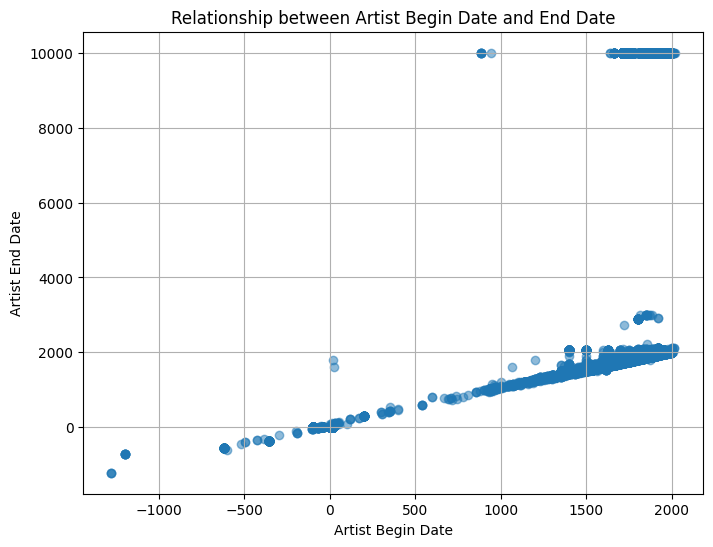

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Artist Begin Date"], df["Artist End Date"], alpha=0.5)

plt.title("Relationship between Artist Begin Date and End Date")
plt.xlabel("Artist Begin Date")
plt.ylabel("Artist End Date")
plt.grid(True)
plt.show()

Zde je vidět, že data odpovídají cca nějaké lineární regresi. Data která jsou mimo křivku jsou podezřelá, protože říkají, že autor žil moc dlouho. Zároveň je divný celý horní cluster, protože má hodnoty roku 10000, toto je chyba v datech a nebo nějaké divné označení chybějících dat ze strany poskytovatele datasetu.

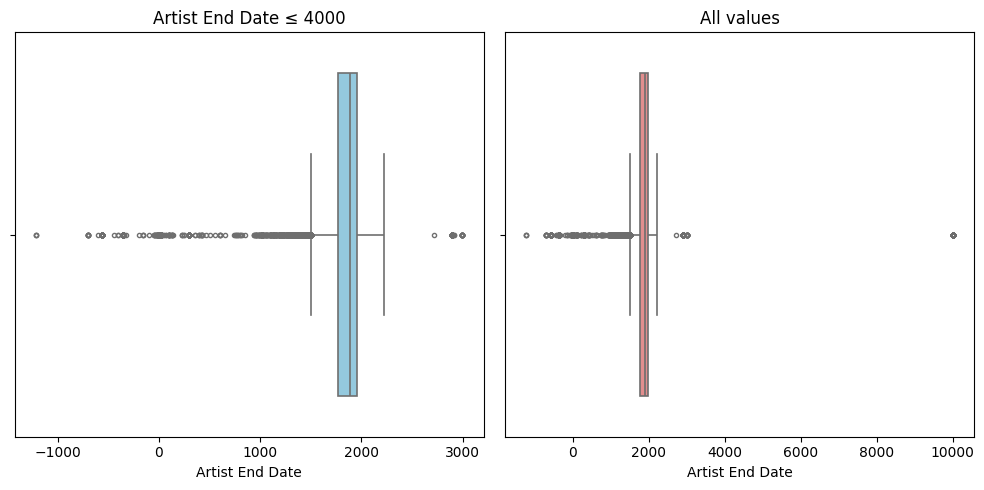

In [24]:
filtered_df = df[df["Artist End Date"] <= 4000]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

sns.boxplot(
    x="Artist End Date",
    data=filtered_df,
    color="skyblue",
    fliersize=3,
    linewidth=1.2,
    ax=axes[0]
)
axes[0].set_title("Artist End Date ≤ 4000")

sns.boxplot(
    x="Artist End Date",
    data=df,
    color="lightcoral",
    fliersize=3,
    linewidth=1.2,
    ax=axes[1]
)
axes[1].set_title("All values")

plt.tight_layout()
plt.show()



Modrý box představuje 1.-3. kvartil dat, tečky jsou outlayery. Z tohoto vidíme, že většina umělců žila v druhé polovině 2. tisiciletí, umělců, kteří pracovali kolem roku 0 je málo a jsou považováni za outlayery. Je zde pár umělců, kteří mají hodnotu 10000, což je pravděpodobně chyba v 
datech, u druhého boxplotu jsem je vynechal.

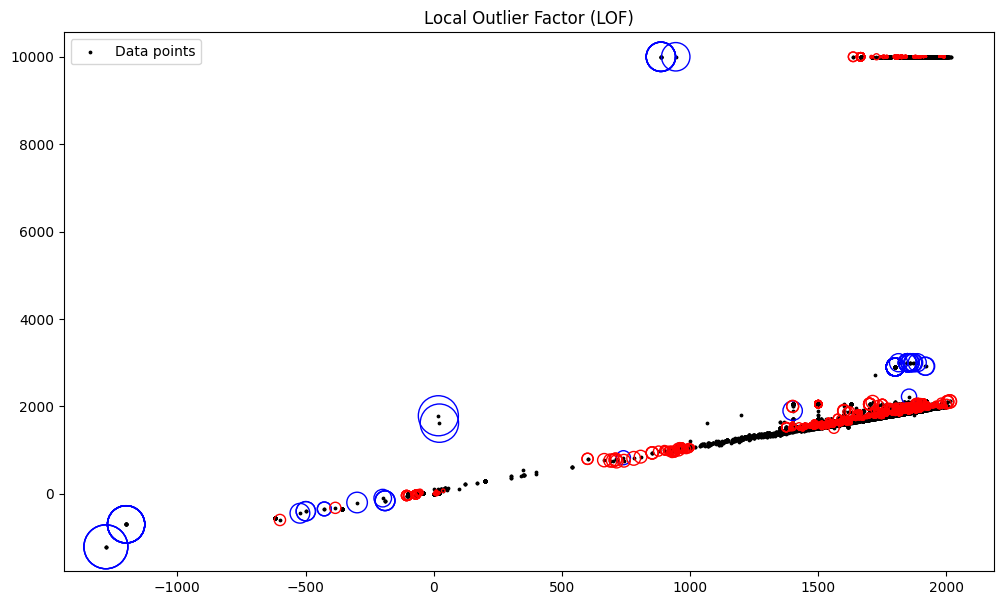

In [25]:
from sklearn.neighbors import LocalOutlierFactor

X = np.array(df[['Artist Begin Date', 'Artist End Date']])
mask = ~np.isnan(X).any(axis=1)
X = X[mask]

clf = LocalOutlierFactor(n_neighbors=50, contamination=0.01)
y_pred = clf.fit_predict(X)
X_scores = clf.negative_outlier_factor_ # the higher, the more normal


plt.figure(figsize=(12, 7))
plt.title("Local Outlier Factor (LOF)")
plt.scatter(X[:, 0], X[:, 1], color='k', s=3., label='Data points')
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

mask_large = radius > 0.1
mask_small = radius <= 0.1

plt.scatter(X[mask_large, 0], X[mask_large, 1],
            s=1000 * radius[mask_large],
            edgecolors='b',
            facecolors='none')

# body s radius <= 1 → červené okraje
plt.scatter(X[mask_small, 0], X[mask_small, 1],
            s=1000 * radius[mask_small],
            edgecolors='r',
            facecolors='none')


legend = plt.legend(loc='upper left')
plt.show()



Zkusil jsem metodu LOF, kde jsem jako outlayery označil body, které mají hustito menší než 0.1. Parametry lof jsem nastavil na 50 sousedů pro výpočet hustoty a odhad počtu outlayeru jsem dal na 1%. Metodu lof jsem použil, protože je schopna odhalit i lokální outlayery, které můžou znamenat, že autor žil třeba 300 let. Na druhou stranu bych odřízl i autory, kteří žili před naším letopočtem a to jen z důvodu, že je jich tam málo. Také bych neodstranil autory, kteří mají zápis z roku 10000 což je očividně chyba.

In [26]:
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy.stats import chi2_contingency
from sklearn.metrics import pairwise_distances_argmin_min

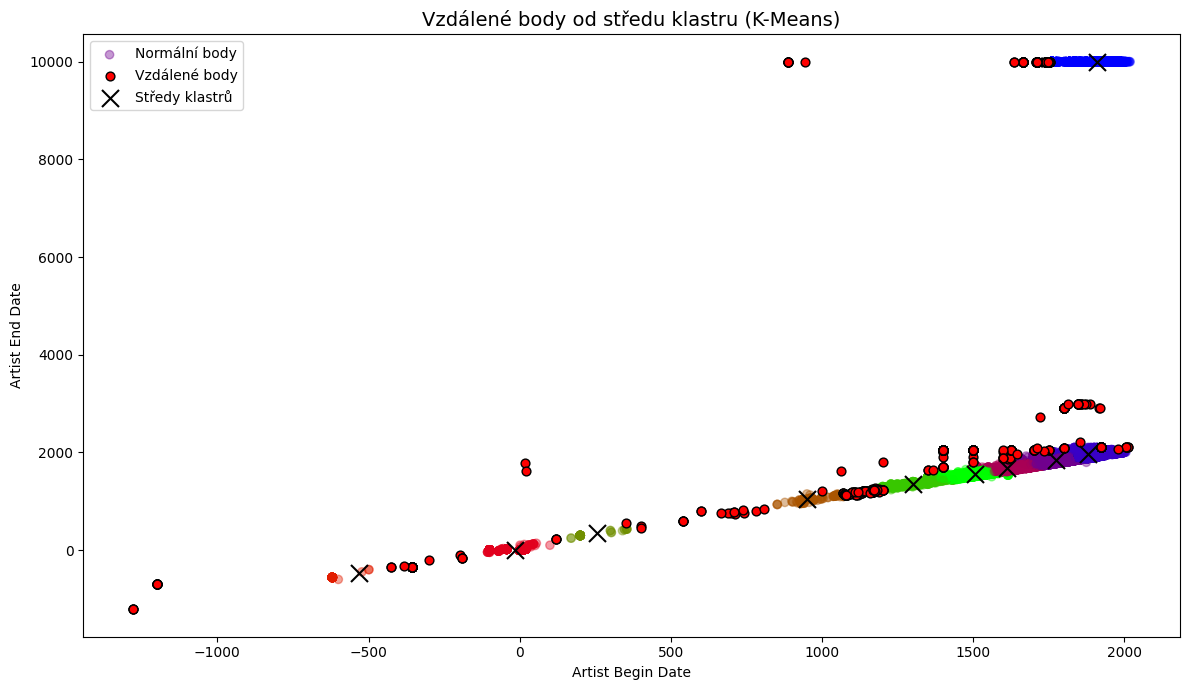

In [27]:
X = df[['Artist Begin Date', 'Artist End Date']].to_numpy()
mask = ~np.isnan(X).any(axis=1)
X = X[mask]

np.random.seed(1)
# initial_centers = X[np.random.choice(range(len(X)), 7, replace=False)]
initial_centers = np.array([
    [2000, 10000],
    [2000, 2000],
    [1500, 1500],
    [1250, 1250],
    [0,0],
    [-1500, -1000],
    [750, 750],
    [500, 500],
    [900, 900],
    [1100, 1100],
])


kmeans = KMeans(
    n_clusters= len(initial_centers),
    init=initial_centers,
    n_init=1,          
    random_state=1
).fit(X)


labels = kmeans.labels_
centers = kmeans.cluster_centers_
_, distances = pairwise_distances_argmin_min(X, centers)


threshold = np.percentile(distances, 99)
outliers_mask = distances > threshold

plt.figure(figsize=(12, 7))
plt.title("Vzdálené body od středu klastru (K-Means)", fontsize=14)

plt.scatter(X[~outliers_mask, 0], X[~outliers_mask, 1],
            c=kmeans.labels_[~outliers_mask], cmap='brg', alpha=0.4, label='Normální body')

plt.scatter(X[outliers_mask, 0], X[outliers_mask, 1],
            c='red', s=40, edgecolors='black', label='Vzdálené body')

plt.scatter(centers[:, 0], centers[:, 1],
            c='black', s=150, marker='x', label='Středy klastrů')
plt.xlabel("Artist Begin Date")
plt.ylabel("Artist End Date")
plt.legend()
plt.tight_layout()
plt.show()

Zkusil jsem požít k-means k hledání outlayeru. Dataset jsem si rozdělil na clustery a odstranil 1% nejvzdálenějších bodů od středu. Kvůli vynucení outlayerů v každém clusteru se jako outlayer označily i některé body, které jsou perfektně v mezích, například body kolem roku 1200. Na druhou stranu jsou označeny všechny body, které jsou mimo pomyslnou křivku přímé úměry a to je správně. Jako bonus by snadno šel označit jako outlayer celý světle modrý cluster, kde jsou roky jako 10000.

### 5) Imputace

In [28]:
# 484956
print(df.shape[0])
df.info()
info = df.count()
filtered = info[info < df.shape[0]]
print("\npříznaky s chybějícími daty\n")
print(filtered)

484956
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Object Number            484956 non-null  object        
 1   Is Highlight             484956 non-null  bool          
 2   Is Timeline Work         484956 non-null  bool          
 3   Is Public Domain         484956 non-null  bool          
 4   Object ID                484956 non-null  int64         
 5   Gallery Number           49541 non-null   object        
 6   Department               484956 non-null  object        
 7   AccessionYear            481054 non-null  datetime64[ns]
 8   Object Name              482690 non-null  category      
 9   Title                    456153 non-null  object        
 10  Culture                  208190 non-null  object        
 11  Period                   91143 non-null   object        
 12  Dynasty  

Chybějící data by šla doplnit například do sloupců AccessionYear, Artist Begin Date, Artist End Date a Artist Role. Naopak třeba sloupec Metadata Date má všechny hodnoty chybějící, takže z něj nezískáme žádnou informaci a můžeme ho zahodit.

In [29]:
df.nunique()

Object Number              481656
Is Highlight                    2
Is Timeline Work                2
Is Public Domain                2
Object ID                  484956
Gallery Number                379
Department                     19
AccessionYear                 154
Object Name                 28631
Title                      245800
Culture                      7313
Period                       1891
Dynasty                       405
Reign                         396
Portfolio                    3959
Constituent ID              48365
Artist Role                  7118
Artist Prefix                8154
Artist Display Name         66949
Artist Display Bio          54658
Artist Suffix                2751
Artist Alpha Sort           66887
Artist Nationality           6945
Artist Begin Date             870
Artist End Date               842
Artist Gender                 290
Artist ULAN URL             38477
Artist Wikidata URL         40972
Object Date                 33197
Object Begin D

In [30]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from itertools import product
from sklearn.preprocessing import StandardScaler

In [31]:
df['Period'] = df['Period'].astype('category')
df['Dynasty'] = df['Dynasty'].astype('category')

AccessionYear má málo chybějících hodnot, takže je velká šance, že se povede odhalit souvislosti a doplnění by mohlo být docela přesné.
Vyberu sloupce které by mohly být relevantní, převedu na číselné reprezentace (nejdřív to převedu na kategorické, protože je to jinak hrozně pomalé a paměťově náročné) a použiju knn imputaci

In [32]:


features = [
    # int
    # 'Artist Begin Date',
    # 'Artist End Date',
    'Object Begin Date',
    'Object End Date',

    # bool
    
]

features_categorical = [
    # 'Department',
    # hodne nan 
#     'Period',
#     'Dynasty',
#     'Culture',
#     'State',
]

# Sloupce jako Period nebo State jsem sice myslel, že budou relevantní, ale vzhledem k hodně chybějícím hodnotám vůbec nepomáhaly


df_knn = df[features + features_categorical + ['AccessionYear']].copy()
df_knn['AccessionYear'] = df_knn['AccessionYear'].dt.year

print(df_knn.isna().sum())
df_knn = df_knn.dropna()


df_knn = pd.get_dummies(df_knn, columns=features_categorical)


# náhodně vyberu jen takto velký vzorek dat z důvodu časové náročnosti
df_knn = df_knn.sample(n=10000)


X, Y = train_test_split(df_knn, test_size=0.3)
Y_org = Y['AccessionYear'].copy()

# Pro knn je potřeba data naškálovat, bez škálování dává i model nátrénovaný s malou MSE nesmyslná data.
num_cols = ['Object Begin Date', 'Object End Date']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

Object Begin Date       0
Object End Date         0
AccessionYear        3902
dtype: int64


In [33]:
mse_real = 100000
best_params = None

param_list = {
    'n_neighbors': list(range(5, 100, 5)),
    'weights': ['uniform', 'distance']
}

param_combinations = list(product(param_list['n_neighbors'], param_list['weights']))


for n_neighbors, weights in param_combinations:
    params = {'n_neighbors': n_neighbors, 'weights': weights}
    imputer = KNNImputer(**params)
    imputer.fit(X)

    Y_test = Y.copy()
    Y_test['AccessionYear'] = np.nan

    Y_test[num_cols] = scaler.transform(Y_test[num_cols])

    Yfit_scaled = imputer.transform(Y_test)
    Yfit = pd.DataFrame(Yfit_scaled, columns=Y_test.columns)

    Yfit[num_cols] = scaler.inverse_transform(Yfit[num_cols])

    y_true = Y_org.values
    y_pred = Yfit['AccessionYear'].values
    mse = mean_squared_error(y_true, y_pred)

    if mse < mse_real:
        mse_real = mse
        best_params = params
    


In [34]:
print(mse_real, best_params)

780.9699608333333 {'n_neighbors': 20, 'weights': 'uniform'}


Chtěl jsem natrénovat imputer na více různých sloupcích, ale to nejde, protože se v nich objevují nan a pokud by se stalo, že potřebuju předpovědět hodnotu kde je nan na nějakém z těch sloupců, bylo by potřeba nějak doplnit i ten nan. Když jsem použil i sloupce jako Dynasty nebo artist begin date, podařilo se mi mse chybu shodit až na 550. Možná by šlo použít dva modely, jeden lepší a jeden horší a ten horší použít jen v případě, kdy nějaká data v řádce chybí.

In [35]:


df_to_impute = df[features + features_categorical + ['AccessionYear']].copy()
df_to_impute['AccessionYear'] = df_to_impute['AccessionYear'].dt.year

df_to_impute[num_cols] = scaler.transform(df_to_impute[num_cols])

df_imputed_values = imputer.transform(df_to_impute)

df_imputed = pd.DataFrame(df_imputed_values, columns=df_to_impute.columns)

df_imputed[num_cols] = scaler.inverse_transform(df_imputed[num_cols])

df['AccessionYear'] = df_imputed['AccessionYear']

In [36]:
df_imputed['AccessionYear'].head()

0    1979.0
1    1980.0
2    1967.0
3    1967.0
4    1967.0
Name: AccessionYear, dtype: float64

In [37]:
df['AccessionYear'] = pd.to_datetime(df_imputed['AccessionYear'].round().astype(int), format='%Y', errors='coerce')

In [38]:
df['AccessionYear'].head()

0   1979-01-01
1   1980-01-01
2   1967-01-01
3   1967-01-01
4   1967-01-01
Name: AccessionYear, dtype: datetime64[ns]

### 6) Příprava Medium

Pro knn je potřeba medium přčevést na nějakou číselnou reprezentaci a odstranin NaN. Použiju dummy sloupce. Toto nemůžu použít bez přípravy, protože unikátních hodnot je hrozně moc a dataset by se nafoukl, což by zbytečně zvedlo výpočetní náročnost.

In [39]:
df["Medium"] = df["Medium"].astype("category")

In [40]:
print(len(df['Medium'].unique()))
df['Medium'].unique()

65908


['Gold', 'Silver', 'Bronze or copper', 'Nickel', 'Pressed glass', ..., 'Drypoint, etching, soft varnish, and roulette', 'Etching on thin white Japan paper', 'Wtaercolor', 'Drypoint  with watercolor additions', 'Etching with watercolor additions']
Length: 65908
Categories (65907, object): ['\r\n', '\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\..., '\r\nBlue faience', '\r\nBrass or bronze', ..., '“Soft paste” porcelain painted with cobalt bl..., '“Steinberger blend” graphite and carbon fiber..., '“Straw opal” glass', '“Straw opal” glass with uranium glass knop']

In [41]:
df['Medium'].isna().sum()

7215

In [42]:
df_medium = df[["Medium"]].copy()

In [43]:
type(df_medium)

pandas.core.frame.DataFrame

Odstraním přebytečné whitespace a převedu na malá písmena, tím zmenším počet unikátních stringů.

In [44]:
def clean_medium_column(df_medium):
    series = df_medium.iloc[:, 0] if isinstance(df_medium, pd.DataFrame) else df_medium

    cleaned = (
        series.astype(str)
        .str.replace(r"[\r\n\t]+", "", regex=True)
        .str.replace(r"\s+", "", regex=True)     
        .str.strip()   
        .str.lower()
    )
    cleaned = cleaned.replace("", pd.NA)

    if isinstance(df_medium, pd.DataFrame):
        return pd.DataFrame({df_medium.columns[0]: cleaned})
    else:
        return cleaned

In [45]:
df_medium = clean_medium_column(df_medium)


In [46]:
df_medium.fillna('unknown');


In [47]:
df_medium['Medium'].nunique()

63286

In [48]:
df_medium["Medium"] = df_medium["Medium"].astype("category")

Tato funkce spočítá počet výskytů hodnoty a pokud je moc malý, shodí ji do kategorie mixed. Tímto zamezím obrovskému zvětšení datasetu. Zároveň předpokládám že hodnoty s malým počtem výskytů jsou buď překlep a nebo velmi unikátní a tudíž nenesou moc informace.

In [49]:
def encode_with_mixed(df, threshold=50, col='Medium'):
    df_encoded = df.copy()
    
    counts = df_encoded[col].value_counts()
    rare_values = counts[counts < threshold].index

    df_encoded[col] = df_encoded[col].replace(rare_values, 'mixed')

    df_encoded = pd.get_dummies(df_encoded, drop_first=False)

    return df_encoded

In [50]:
df_medium = encode_with_mixed(df_medium)

In [51]:
df_medium.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Columns: 707 entries, Medium_mixed to Medium_zincograph
dtypes: bool(707)
memory usage: 327.0 MB


In [52]:
print(df_medium.shape[1])

707


In [53]:
print(type(df_medium), type(df))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


In [54]:
# pridani vysledku do puvodniho datasetu
df = pd.concat([df.drop(columns=['Medium']), df_medium], axis=1)

In [55]:
df.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,Culture,Period,Dynasty,Reign,Portfolio,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL,Object Date,Object Begin Date,Object End Date,Dimensions,Credit Line,Geography Type,City,State,County,Country,Region,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL,Medium_mixed,Medium_[nomediumavailable],Medium_acryliconcanvas,Medium_agate,Medium_alabaster,Medium_albumenphotograph,"Medium_albumenphotograph,cabinetcard","Medium_albumenprintphotograph,cabinetcard",Medium_albumensilverprint,Medium_albumensilverprintfromglassnegative,Medium_albumensilverprintfromglassnegativewithappliedcolor,Medium_albumensilverprintfrompapernegative,Medium_albumensilverprints,Medium_albumensilverprintsfromglassnegatives,Medium_albumensilverprintwithappliedcolor,Medium_albumleaf;inkandcoloronsilk,Medium_amber,Medium_amethyst,Medium_applied,Medium_aquatint,Medium_bamboo,"Medium_bamboo,wood,fiber","Medium_barkcloth,pigment",Medium_basalt,Medium_beryl,Medium_blackchalk,Medium_blackchalkonpaper,Medium_blackcrayononpaper,"Medium_blackink,graywash",Medium_blackworkandengraving,Medium_blownglass,Medium_blownpattern-moldedglass,Medium_bluefaience,Medium_blueglazedsteatite,Medium_bobbinlace,"Medium_bobbinlace,milaneselace","Medium_bobbinlace,pointd'angleterre",Medium_bone,Medium_bone;incisedandinlaidwithpaint,"Medium_bone;tinted,incised,andinlaidwithpaint",Medium_bonechina,Medium_book,Medium_boxwood,Medium_brass,"Medium_brass,iron","Medium_brass,nickel-silver",Medium_bromoilprint,Medium_bronze,"Medium_bronze,cast","Medium_bronze,cast-single","Medium_bronze,gold","Medium_bronze,struck",Medium_bronze;cast,Medium_bronzeorcopperalloy,Medium_camelidhair,"Medium_camelidhair,cotton",Medium_cane,Medium_carbonprint,Medium_carnelian,Medium_carvedoak,Medium_castiron,Medium_ceramic,"Medium_ceramic,glaze","Medium_ceramic,paint","Medium_ceramic,pigment","Medium_ceramic,slip","Medium_ceramic,slip,pigment",Medium_chalcedony,"Medium_champlevéenamel,copper-gilt",Medium_charcoal,"Medium_charcoal,gouacheandgoldpaint",Medium_charcoalonpaper,Medium_chlorite,Medium_chromogenicprint,Medium_chromolithograph,Medium_chromolithographwithhand-coloring,Medium_clay,Medium_clay(unfired),"Medium_clay,glazed",Medium_cloisonnéenamel,Medium_collotype,Medium_collotypeandletterpress,Medium_coloredlithograph,Medium_coloredlithograph;thirdstateofthree(armelhault&bocher),Medium_coloretching,Medium_colorfilmtransparency,Medium_colorlessglass,"Medium_colorlessglass,vitreouspaintandsilverstain",Medium_colorlinocut,Medium_colorlithograph,Medium_colorlithographs,Medium_colorwoodcut,Medium_commercialcolorlithograph,Medium_commercialcolorlithographreproducingdrawing,Medium_commercialcolorlithographs,Medium_commercialcolorlithographwithmetaltrim,Medium_commercialcolorphotolithograph,Medium_commercialcolorprocess,Medium_commerciallithograph,Medium_commerciallithographswithhalf-tonephotograph,Medium_commercialphotolithograph,Medium_commercialprintingprocess,Medium_commercialreliefprocess,Medium_copper,Medium_copper(cast),"Medium_copper(hammered),gilt","Medium_copper,bronze","Medium_copper,gilt","Medium_copper,gold,enamel","Medium_copper-goldalloy(shakudō),gold","Medium_copper-goldalloy(shakudō),gold,copper","Medium_copper-goldalloy(shakudō),gold,silver","Medium_copper-goldalloy(shakudō),gold,silver,copper","Medium_copper-silveralloy(shibuichi),gold","Medium_copper-silveralloy(shibuichi),gold,copper","Medium_copper-silveralloy(shibuichi),gold,copper-goldalloy(shakudō)","Medium_copper-silveralloy(shibuichi),gold,silver",Medium_copperalloy,Medium_copperplate,Medium_cotton,"Medium_cotton,camelidhair","Medium_

### 7) Extrakce hodnot z dimensions

In [56]:
df[['Dimensions']].head(100)



,Dimensions
0,Dimensions unavailable
1,Dimensions unavailable
2,Diam. 11/16 in. (1.7 cm)
3,Diam. 11/16 in. (1.7 cm)
4,Diam. 11/16 in. (1.7 cm)
5,Diam. 11/16 in. (1.7 cm)
6,Diam. 11/16 in. (1.7 cm)
7,Diam. 11/16 in. (1.7 cm)
8,Diam. 11/16 in. (1.7 cm)
9,Dimensions unavailable


In [57]:
df['Dimensions'].unique()

array(['Dimensions unavailable', 'Diam. 11/16 in. (1.7 cm)',
       'Diam. 1/2 in. (1.3 cm)', ...,
       'Plate: 8 3/4 × 5 7/8 in. (22.2 × 15 cm)\r\nSheet: 12 3/16 × 8 3/8 in. (31 × 21.2 cm)',
       '2 pages, 30 unnumbered leaves of plates (some color and folded) : illustrations (some color) ; Height: 11 7/16 in. (29 cm)',
       'Image: 6 5/8 × 11 3/4 in. (16.9 × 29.9 cm)\r\nPlate: 8 15/16 × 13 5/8 in. (22.7 × 34.6 cm)\r\nSheet: 10 13/16 × 15 9/16 in. (27.4 × 39.5 cm)'],
      dtype=object)

In [58]:
print(df.loc[34, 'Dimensions'])

Overall: 19 7/16 x 13 x 9 1/4 in. (49.4 x 33 x 23.5 cm); 352 oz. 18 dwt. (10977 g)
Body: H. 18 7/8 in. (47.9 cm)
Cover: 4 1/4 x 4 13/16 in. (10.8 x 12.2 cm); 19 oz. 6 dwt. (600.1 g)


In [59]:
df_dimensions = df[["Dimensions"]].copy()

Hodnoty v centimetrech jsou v zavorkách, pokud jsou v závorkách 3 čísla, můžeme je označit za w, h, d. Pokud jsou zde jen dva, pravděpodobně se jedná o plátno, někdy jen jeden, to hádám že je třeba poloměr koule.

In [60]:
df_dimensions.sample(n=100)

,Dimensions
188116,H. 105 in. x W. 10 in. × D. 13 in. (266.7 × 25...
174521,7.9 x 7.9 cm (3 1/8 x 3 1/8 in.)
132088,L. 9 x W. 1 inch\r\n22.9 x 2.5 cm
288421,Image: 2 15/16 × 4 7/16 in. (7.5 × 11.3 cm)\r\...
434597,Sheet: 9 3/4 × 13 11/16 in. (24.7 × 34.8 cm)
59511,12 3/4 x 13 1/4 in. (32.38 x 33.66 cm)
68764,NaN
52605,H. 3 5/8 in. (9.2 cm); W. 5 1/4 in. (13.3 cm)
398156,NaN
404927,L. 1 3/8 in. (3.5 cm)


Tato funkce pomocí regexu najde první závorku která obsahuje 'cm' a extrahuje z ní všechna čísla.

In [61]:
def extract_cm_values(dim_str):
    if not isinstance(dim_str, str):
        return [None, None, None]
    
    match = re.search(r'\(([^)]*cm[^)]*)\)', dim_str)
    if not match:
        return [None, None, None]
    
    inside = match.group(1)
    
    numbers = re.findall(r'\d+(?:\.\d+)?', inside)
    
    if not numbers:
        return [None, None, None]
    
    nums = [float(x) for x in numbers]
    
    while len(nums) < 3:
        nums.append(None)
    
    return nums[:3]

In [62]:
df_dimensions[['Dim1_cm', 'Dim2_cm', 'Dim3_cm']] = df_dimensions['Dimensions'].apply(lambda x: pd.Series(extract_cm_values(x)))

In [63]:
df_dimensions.head(100)

,Dimensions,Dim1_cm,Dim2_cm,Dim3_cm
0,Dimensions unavailable,NaN,NaN,NaN
1,Dimensions unavailable,NaN,NaN,NaN
2,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
3,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
4,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
5,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
6,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
7,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
8,Diam. 11/16 in. (1.7 cm),1.7,NaN,NaN
9,Dimensions unavailable,NaN,NaN,NaN


In [64]:
# df = pd.concat([df.drop(columns=['Medium']), df_medium], axis=1)
df = pd.concat([df, df_dimensions.drop(columns=['Dimensions'])], axis=1)

In [65]:
df.head(10)

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,Culture,Period,Dynasty,Reign,Portfolio,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL,Object Date,Object Begin Date,Object End Date,Dimensions,Credit Line,Geography Type,City,State,County,Country,Region,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL,Medium_mixed,Medium_[nomediumavailable],Medium_acryliconcanvas,Medium_agate,Medium_alabaster,Medium_albumenphotograph,"Medium_albumenphotograph,cabinetcard","Medium_albumenprintphotograph,cabinetcard",Medium_albumensilverprint,Medium_albumensilverprintfromglassnegative,Medium_albumensilverprintfromglassnegativewithappliedcolor,Medium_albumensilverprintfrompapernegative,Medium_albumensilverprints,Medium_albumensilverprintsfromglassnegatives,Medium_albumensilverprintwithappliedcolor,Medium_albumleaf;inkandcoloronsilk,Medium_amber,Medium_amethyst,Medium_applied,Medium_aquatint,Medium_bamboo,"Medium_bamboo,wood,fiber","Medium_barkcloth,pigment",Medium_basalt,Medium_beryl,Medium_blackchalk,Medium_blackchalkonpaper,Medium_blackcrayononpaper,"Medium_blackink,graywash",Medium_blackworkandengraving,Medium_blownglass,Medium_blownpattern-moldedglass,Medium_bluefaience,Medium_blueglazedsteatite,Medium_bobbinlace,"Medium_bobbinlace,milaneselace","Medium_bobbinlace,pointd'angleterre",Medium_bone,Medium_bone;incisedandinlaidwithpaint,"Medium_bone;tinted,incised,andinlaidwithpaint",Medium_bonechina,Medium_book,Medium_boxwood,Medium_brass,"Medium_brass,iron","Medium_brass,nickel-silver",Medium_bromoilprint,Medium_bronze,"Medium_bronze,cast","Medium_bronze,cast-single","Medium_bronze,gold","Medium_bronze,struck",Medium_bronze;cast,Medium_bronzeorcopperalloy,Medium_camelidhair,"Medium_camelidhair,cotton",Medium_cane,Medium_carbonprint,Medium_carnelian,Medium_carvedoak,Medium_castiron,Medium_ceramic,"Medium_ceramic,glaze","Medium_ceramic,paint","Medium_ceramic,pigment","Medium_ceramic,slip","Medium_ceramic,slip,pigment",Medium_chalcedony,"Medium_champlevéenamel,copper-gilt",Medium_charcoal,"Medium_charcoal,gouacheandgoldpaint",Medium_charcoalonpaper,Medium_chlorite,Medium_chromogenicprint,Medium_chromolithograph,Medium_chromolithographwithhand-coloring,Medium_clay,Medium_clay(unfired),"Medium_clay,glazed",Medium_cloisonnéenamel,Medium_collotype,Medium_collotypeandletterpress,Medium_coloredlithograph,Medium_coloredlithograph;thirdstateofthree(armelhault&bocher),Medium_coloretching,Medium_colorfilmtransparency,Medium_colorlessglass,"Medium_colorlessglass,vitreouspaintandsilverstain",Medium_colorlinocut,Medium_colorlithograph,Medium_colorlithographs,Medium_colorwoodcut,Medium_commercialcolorlithograph,Medium_commercialcolorlithographreproducingdrawing,Medium_commercialcolorlithographs,Medium_commercialcolorlithographwithmetaltrim,Medium_commercialcolorphotolithograph,Medium_commercialcolorprocess,Medium_commerciallithograph,Medium_commerciallithographswithhalf-tonephotograph,Medium_commercialphotolithograph,Medium_commercialprintingprocess,Medium_commercialreliefprocess,Medium_copper,Medium_copper(cast),"Medium_copper(hammered),gilt","Medium_copper,bronze","Medium_copper,gilt","Medium_copper,gold,enamel","Medium_copper-goldalloy(shakudō),gold","Medium_copper-goldalloy(shakudō),gold,copper","Medium_copper-goldalloy(shakudō),gold,silver","Medium_copper-goldalloy(shakudō),gold,silver,copper","Medium_copper-silveralloy(shibuichi),gold","Medium_copper-silveralloy(shibuichi),gold,copper","Medium_copper-silveralloy(shibuichi),gold,copper-goldalloy(shakudō)","Medium_copper-silveralloy(shibuichi),gold,silver",Medium_copperalloy,Medium_copperplate,Medium_cotton,"Medium_cotton,camelidhair","Medium_